In [1]:
import math

In [2]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            ''' backward function is always grad of out wrt self * out.grad
            helps to write equation out = self + other. Then find partial L / partial self
            '''
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __sub__(self, other):
        return self + -1 * other
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += out.grad * other * self.data ** (other -1) 
            # other.grad += 
        out._backward = _backward
        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')

        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        

In [3]:
import re
from graphviz import Digraph


class ScrollableGraph:
    """
    wraps a Digraph so the notebook shows it at full size in a scroll box
    instead of shrinking the whole graph down to the cell width

    ctrl/cmd + wheel over the graph zooms (where the notebook runs output js)
    """
    def __init__(self, dot, height=520, scale=1.0):
        self.dot = dot
        self.height = height   # px, height of the scroll box
        self.scale = scale     # 1.0 = graphviz's natural size

    def __getattr__(self, name):
        # hide graphviz's own repr hooks: its _repr_mimebundle_ would otherwise be
        # found here and win over _repr_html_, so the wrapper would do nothing
        if name.startswith('_repr_') or name.startswith('_ipython_'):
            raise AttributeError(name)
        # anything else (render, source, view, ...) falls through to the Digraph
        return getattr(self.dot, name)

    def _repr_html_(self):
        svg = self.dot.pipe(format='svg').decode('utf-8')
        svg = svg[svg.index('<svg'):]  # drop the xml/doctype preamble so the svg can be inlined

        # graphviz sizes the svg in points; browsers render 1pt as 4/3 px
        w, h = (float(v) for v in re.search(
            r'width="([\d.]+)pt"\s+height="([\d.]+)pt"', svg).groups())
        w, h = round(w * 4 / 3 * self.scale), round(h * 4 / 3 * self.scale)

        # let the svg fill the sized inner div rather than carry its own dimensions:
        # notebook css often forces `svg {max-width: 100% !important}`, which would
        # otherwise shrink the graph back to the cell width and leave nothing to scroll
        svg = re.sub(r'width="[\d.]+pt"\s+height="[\d.]+pt"',
                     'width="100%" height="100%" preserveAspectRatio="xMinYMin meet"',
                     svg, count=1)

        uid = 'g%d' % id(self)
        # the width must be a *definite* length: vs code renders output in an
        # auto-sized iframe, so `width:100%` resolves against a shrink-to-fit box
        # and the div just grows to the graph's width -> clipped, no scrollbar.
        # 1vw is the output viewport, which is a real width, so overflow can kick in
        return f'''
<div id="{uid}" style="overflow:auto !important; width:calc(100vw - 48px); max-width:{w}px;
     max-height:{self.height}px; resize:both; border:1px solid #ddd; border-radius:4px;
     background:#fff; box-sizing:border-box;">
  <div style="width:{w}px; height:{h}px;" id="{uid}-inner">{svg}</div>
</div>
<script>
(function() {{
  var box = document.getElementById("{uid}"), inner = document.getElementById("{uid}-inner");
  if (!box || !inner) return;
  var w = {w}, h = {h}, z = 1;
  box.addEventListener("wheel", function(e) {{
    if (!e.ctrlKey && !e.metaKey) return;   // plain wheel keeps scrolling the box
    e.preventDefault();
    z = Math.min(4, Math.max(0.2, z * (e.deltaY < 0 ? 1.1 : 1 / 1.1)));
    inner.style.width = (w * z) + "px";
    inner.style.height = (h * z) + "px";
    box.style.maxWidth = (w * z) + "px";
  }}, {{passive: false}});
}})();
</script>'''


def trace(root):
    """
    builds a set of all nodes and edges in a graph
    """
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, height=520, scale=1.0):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)    
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph,create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return ScrollableGraph(dot, height=height, scale=scale)


In [4]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')

In [5]:
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

In [6]:
draw_dot(L)

In [7]:
# inputs x1,x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
# weights w1, w2
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
# bias of the neuron
b = Value(6.8813735870195432,label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label ='x1w1'
x2w2 = x2*w2; x2w2.label ='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2+b; n.label='n'
o = n.tanh() 
o.label = 'o'

In [8]:
draw_dot(o)

In [9]:
o.backward()

In [10]:
import random

In [11]:
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self, x):
        ## Neuron(x)
        act = sum([wi*xi for wi, xi in zip(self.w, x)], self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        # n out is number of neurons in the layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [20]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [29]:
n = MLP(3, [4,4,1])


In [30]:
stepi = []
lossi = []

for _ in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    #print(ypred)
    loss = sum(((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)))

    print(loss)
    # backward pass
    for p in n.parameters():
        p.grad = 0
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    stepi.append(_)
    lossi.append(loss.data)
    
    

Value(data=6.9214065970446885)
Value(data=4.402952916020245)
Value(data=1.5464155609771935)
Value(data=0.6231668661061538)
Value(data=0.3677410438933827)
Value(data=0.2555538112358247)
Value(data=0.191046419295367)
Value(data=0.15050419775744414)
Value(data=0.1231633287417159)
Value(data=0.10369032958550871)
Value(data=0.08921753276757655)
Value(data=0.07809150123192513)
Value(data=0.06930189733400652)
Value(data=0.06220088018977504)
Value(data=0.05635598482224124)
Value(data=0.051468547778410756)
Value(data=0.0473262522003136)
Value(data=0.043774356245494826)
Value(data=0.04069761277533171)
Value(data=0.03800854667571245)


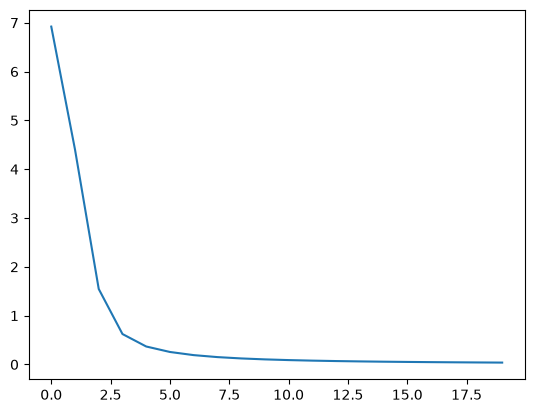

In [31]:
import matplotlib.pyplot as plt
plt.plot(stepi,lossi)

In [32]:
ypred

[Value(data=0.9189727498088605),
 Value(data=-0.948890976908629),
 Value(data=-0.887423069153219),
 Value(data=0.8728881051909786)]